In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from utils import automated_pipeline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [61]:
file_raw = r'E:\airta drafts\PREDIKSI KADAR HB\data\raw\erm_hd.xlsx'
df_raw = pd.read_excel(file_raw)

df = automated_pipeline(df_raw)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_pasien        639 non-null    int64         
 1   tgl_pemeriksaan  639 non-null    datetime64[ns]
 2   usia             639 non-null    Int64         
 3   jk               639 non-null    Int64         
 4   eritrosit        639 non-null    float64       
 5   hematokrit       639 non-null    float64       
 6   MCHC             639 non-null    float64       
 7   MCH              639 non-null    float64       
 8   MCV              639 non-null    float64       
 9   hemoglobin       639 non-null    float64       
 10  leukosit         639 non-null    Int64         
 11  trombosit        639 non-null    Int64         
 12  epo              639 non-null    Int64         
dtypes: Int64(5), datetime64[ns](1), float64(6), int64(1)
memory usage: 68.1 KB


In [62]:
df = df.sort_values(by=['id_pasien', 'tgl_pemeriksaan']).reset_index(drop=True)

#LAG FEATURE 
df['hb_lag'] = df.groupby('id_pasien')['hemoglobin'].shift(1)
df['hb_lag2'] = df.groupby('id_pasien')['hemoglobin'].shift(2)

df['hb_delta'] = df['hb_lag'] - df['hb_lag2']

df['inflamasi'] = (df['leukosit'] / 10000) * (df['trombosit'] / 150000)
df['epo_resist'] = df['epo'] / (df['inflamasi'] + 1)

lag_cols = ['hb_lag', 'hb_lag2']
df = df.dropna(subset=lag_cols).reset_index(drop=True)

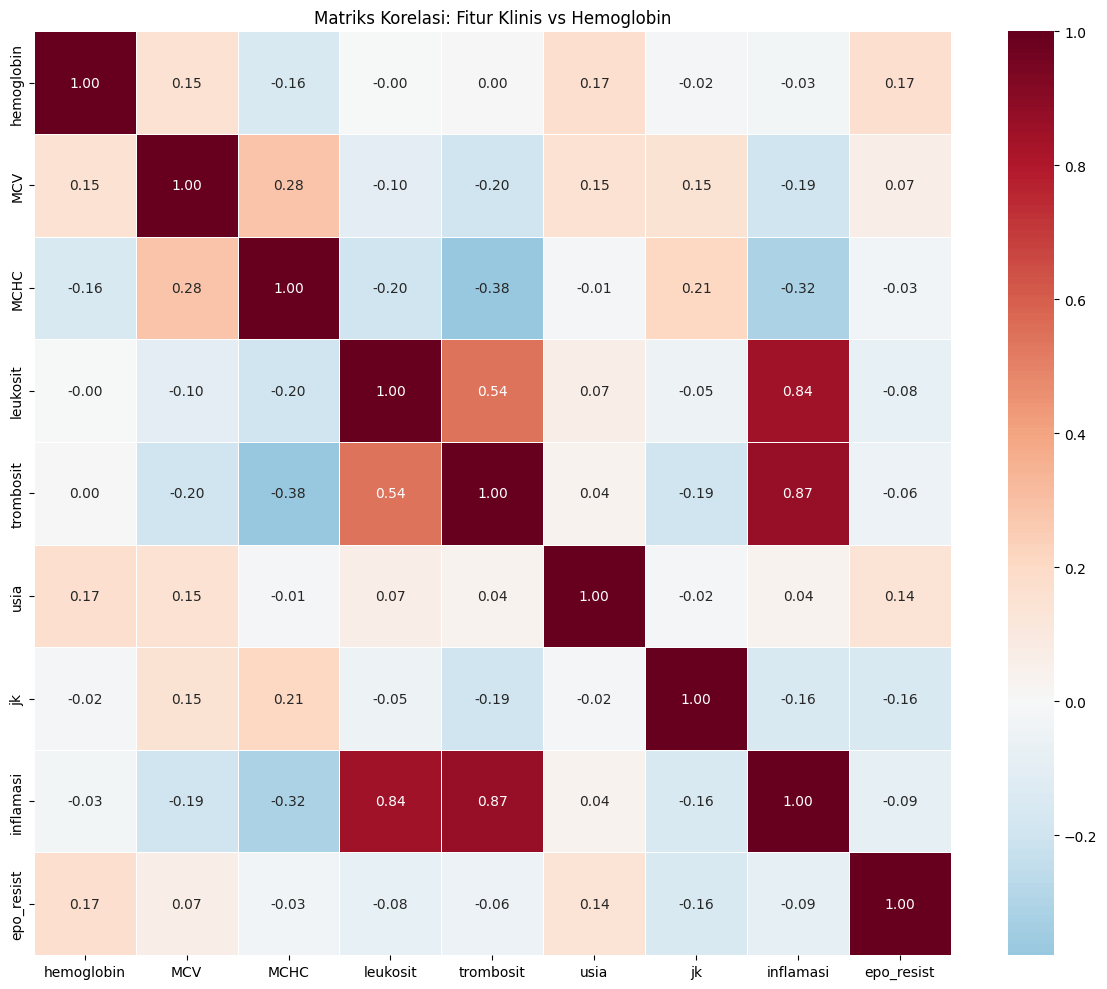

In [63]:
cols_to_corr = [
    'hemoglobin', 'MCV', 'MCHC', 'leukosit', 'trombosit', 'usia', 'jk', 'inflamasi', 'epo_resist'
]

corr_matrix = df[cols_to_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)

plt.title("Matriks Korelasi: Fitur Klinis vs Hemoglobin")
plt.tight_layout()
plt.show()

In [64]:
#MENENTUKAN FITUR X DAN TARGET Y
X = df.drop(columns=['id_pasien', 'tgl_pemeriksaan', 'hemoglobin', 'hematokrit', 'eritrosit', 'MCH', 'epo', 'inflamasi'])
y = df['hemoglobin']

#SPLIT 80:20 BERDASARKAN KRONOLOGIS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    shuffle=False
)

print(f"Total baris data: {len(df)}")
print(f"Jumlah Data Latih (80%): {len(X_train)}")
print(f"Jumlah Data Uji (20%): {len(X_test)}")
print("-" * 30)
print("Fitur yang digunakan (X):", X.columns.tolist())

Total baris data: 497
Jumlah Data Latih (80%): 397
Jumlah Data Uji (20%): 100
------------------------------
Fitur yang digunakan (X): ['usia', 'jk', 'MCHC', 'MCV', 'leukosit', 'trombosit', 'hb_lag', 'hb_lag2', 'hb_delta', 'epo_resist']


In [65]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print(f"Total baris di X_train: {len(X_train)}")
print("-" * 30)

for i, (train_index, val_index) in enumerate(tscv.split(X_train)):
    print(f"Iterasi ke-{i+1}:")
    print(f"  Jumlah Data Latih: {len(train_index)} baris (Indeks {train_index[0]} s/d {train_index[-1]})")
    print(f"  Jumlah Data Validasi: {len(val_index)} baris (Indeks {val_index[0]} s/d {val_index[-1]})")
    print("-" * 30)

Total baris di X_train: 397
------------------------------
Iterasi ke-1:
  Jumlah Data Latih: 67 baris (Indeks 0 s/d 66)
  Jumlah Data Validasi: 66 baris (Indeks 67 s/d 132)
------------------------------
Iterasi ke-2:
  Jumlah Data Latih: 133 baris (Indeks 0 s/d 132)
  Jumlah Data Validasi: 66 baris (Indeks 133 s/d 198)
------------------------------
Iterasi ke-3:
  Jumlah Data Latih: 199 baris (Indeks 0 s/d 198)
  Jumlah Data Validasi: 66 baris (Indeks 199 s/d 264)
------------------------------
Iterasi ke-4:
  Jumlah Data Latih: 265 baris (Indeks 0 s/d 264)
  Jumlah Data Validasi: 66 baris (Indeks 265 s/d 330)
------------------------------
Iterasi ke-5:
  Jumlah Data Latih: 331 baris (Indeks 0 s/d 330)
  Jumlah Data Validasi: 66 baris (Indeks 331 s/d 396)
------------------------------


In [66]:
df_check = df.copy()
df_check['set'] = 'train'
df_check.loc[X_test.index, 'set'] = 'test'

df_check[['id_pasien', 'tgl_pemeriksaan', 'hb_lag', 'hb_lag2', 'hemoglobin', 'set']].iloc[
    len(X_train)-5 : len(X_train)+5
]

,id_pasien,tgl_pemeriksaan,hb_lag,hb_lag2,hemoglobin,set
392,53,2025-10-01,9.3,8.6,8.6,train
393,53,2025-11-01,8.6,9.3,7.0,train
394,53,2025-12-01,7.0,8.6,8.6,train
395,53,2026-01-01,8.6,7.0,7.7,train
396,54,2025-05-01,7.3,8.4,7.6,train
397,54,2025-06-01,7.6,7.3,8.6,test
398,54,2025-07-01,8.6,7.6,9.5,test
399,54,2025-08-01,9.5,8.6,9.0,test
400,54,2025-09-01,9.0,9.5,8.2,test
401,54,2025-10-01,8.2,9.0,8.5,test


In [67]:
from sklearn.linear_model import Lasso, ElasticNet, BayesianRidge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import time

best_models = {}

# GRID SEARCH SVR
print("Menjalankan Grid Search SVR")
param_grid_svr = {
    # (0.01 - 1.0) untuk regulasi kuat
    'model__C': [0.01, 0.1, 0.5, 1], 
    
    # memperbesar epsilon agar model lebih 'cuek' terhadap fluktuasi kecil Hb
    'model__epsilon': [0.2, 0.5, 0.8], 
    
    # gamma sangat kecil agar kurva tidak terlalu meliuk-liuk
    'model__gamma': [0.0001, 0.001, 'scale'] 
}

pipe_svr = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', SVR(kernel='rbf'))
])

grid_svr = GridSearchCV(pipe_svr, param_grid_svr, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_svr.fit(X_train, y_train)

latency_svr = time.time() - start_time
best_models['SVR'] = {
    'best_mae': -grid_svr.best_score_, 
    'params': grid_svr.best_params_, 
    'latency': latency_svr
}

# 2. GRID SEARCH RANDOM FOREST
print("Menjalankan Grid Search Random Forest...")
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 5]
}
rf = RandomForestRegressor(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_rf.fit(X_train, y_train)
latency_rf = time.time() - start_time
best_models['RF'] = {'best_mae': -grid_rf.best_score_, 'params': grid_rf.best_params_, 'latency': latency_rf}

# 3. GRID SEARCH LIGHTGBM
print("Menjalankan Grid Search LightGBM...")
param_grid_lgbm = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [7, 15]
}
lgbm = LGBMRegressor(random_state=42, verbose=-1)
grid_lgbm = GridSearchCV(lgbm, param_grid_lgbm, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_lgbm.fit(X_train, y_train)
latency_lgbm = time.time() - start_time
best_models['LGBM'] = {'best_mae': -grid_lgbm.best_score_, 'params': grid_lgbm.best_params_, 'latency': latency_lgbm}

# 4. GRID SEARCH XGBOOST
print("Menjalankan Grid Search XGBoost...")
param_grid_xgb = {
    'n_estimators': [100, 150],
    'max_depth': [3, 4],                 
    'learning_rate': [0.01, 0.05],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'reg_alpha': [0.1, 1.0],
    'reg_lambda': [1.0, 5.0]
}
xgb = XGBRegressor(random_state=42, n_jobs=-1)
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_xgb.fit(X_train, y_train)
latency_xgb = time.time() - start_time
best_models['XGB'] = {'best_mae': -grid_xgb.best_score_, 'params': grid_xgb.best_params_, 'latency': latency_xgb}


# 5. GRID SEARCH LASSO
print("Menjalankan Grid Search Lasso...")
param_grid_lasso = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}
pipe_lasso = Pipeline([('scaler', StandardScaler()), ('model', Lasso(random_state=42))])
grid_lasso = GridSearchCV(pipe_lasso, param_grid_lasso, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_lasso.fit(X_train, y_train)
best_models['Lasso'] = {'best_mae': -grid_lasso.best_score_, 'params': grid_lasso.best_params_, 'latency': time.time() - start_time}

# 6. GRID SEARCH ELASTICNET
print("Menjalankan Grid Search ElasticNet...")
param_grid_en = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.2, 0.5, 0.8]
}
pipe_en = Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(random_state=42))])
grid_en = GridSearchCV(pipe_en, param_grid_en, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_en.fit(X_train, y_train)
best_models['ElasticNet'] = {'best_mae': -grid_en.best_score_, 'params': grid_en.best_params_, 'latency': time.time() - start_time}

# 7. GRID SEARCH BAYESIAN RIDGE 
print("Menjalankan Grid Search Bayesian Ridge...")
param_grid_br = {
    'model__max_iter': [300, 600],
    'model__tol': [1e-3, 1e-4]
}
pipe_br = Pipeline([('scaler', StandardScaler()), ('model', BayesianRidge())])
grid_br = GridSearchCV(pipe_br, param_grid_br, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_br.fit(X_train, y_train)
best_models['Bayesian'] = {'best_mae': -grid_br.best_score_, 'params': grid_br.best_params_, 'latency': time.time() - start_time}

from sklearn.linear_model import LinearRegression

# 8.GRID SEARCH LINEAR REGRESSION (BASELINE)
# Kosong karena tidak ada parameter yang di-tuning
param_grid_lr = {} 

pipe_lr = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)

start_time = time.time()
grid_lr.fit(X_train, y_train)
latency_lr = time.time() - start_time

best_models['Linear'] = {
    'best_mae': -grid_lr.best_score_, 
    'params': 'N/A', 
    'latency': latency_lr
}


Menjalankan Grid Search SVR
Menjalankan Grid Search Random Forest...
Menjalankan Grid Search LightGBM...
Menjalankan Grid Search XGBoost...
Menjalankan Grid Search Lasso...
Menjalankan Grid Search ElasticNet...
Menjalankan Grid Search Bayesian Ridge...


In [68]:
df_hasil = pd.DataFrame(best_models).T
df_hasil = df_hasil.reset_index().rename(columns={'index': 'Algoritma'})
df_hasil = df_hasil.sort_values('best_mae')

print("HASIL PERBANDINGAN GRID SEARCH (TSCV)")
print("-" * 50)
print(df_hasil[['Algoritma', 'best_mae', 'latency']])

HASIL PERBANDINGAN GRID SEARCH (TSCV)
--------------------------------------------------
    Algoritma  best_mae    latency
5  ElasticNet  0.648413   0.264515
4       Lasso   0.64942   0.161095
7      Linear  0.652478   0.044441
6    Bayesian  0.655165   0.108633
2        LGBM  0.667954   1.934339
1          RF  0.678426   7.739823
3         XGB  0.692528  12.015218
0         SVR  0.703561    1.05273


In [69]:
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models_final = {}

# Baseline
models_final["Linear Regression (Baseline)"] = LinearRegression()

# Linear Models (Gunakan best_estimator_ agar StandardScaler ikut terbawa)
models_final["Lasso"] = grid_lasso.best_estimator_
models_final["ElasticNet"] = grid_en.best_estimator_
models_final["Bayesian Ridge"] = grid_br.best_estimator_

# Non-Linear (Kernel)
models_final["SVR"] = grid_svr.best_estimator_

# Tree-based Models
models_final["Random Forest"] = RandomForestRegressor(**grid_rf.best_params_, random_state=42)
models_final["LightGBM"] = LGBMRegressor(**grid_lgbm.best_params_, random_state=42, verbose=-1)
models_final["XGBoost"] = XGBRegressor(**grid_xgb.best_params_, random_state=42)

# 2. Proses Evaluasi pada X_test 
final_results = []

for name, model in models_final.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Hitung Metrik
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Mapping Latency dari best_models
    if name == "Linear Regression (Baseline)":
        lat = 0 
    elif name == "Random Forest": lat = best_models['RF']['latency']
    elif name == "XGBoost": lat = best_models['XGB']['latency']
    elif name == "LightGBM": lat = best_models['LGBM']['latency'] 
    elif name == "SVR": lat = best_models['SVR']['latency']
    elif name == "Lasso": lat = best_models['Lasso']['latency']
    elif name == "ElasticNet": lat = best_models['ElasticNet']['latency']
    elif name == "Bayesian Ridge": lat = best_models['Bayesian']['latency']
    else: lat = 0

    final_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Latency (s)": lat
    })

df_final = pd.DataFrame(final_results).sort_values(by="MAE")
print("\n" + "="*85)
print("HASIL EVALUASI AKHIR PADA DATA TEST (20%)")
print("="*85)
print(df_final.to_string(index=False))
print("="*85)


HASIL EVALUASI AKHIR PADA DATA TEST (20%)
                       Model      MAE     RMSE       R2  Latency (s)
                    LightGBM 0.657725 0.832047 0.434694     1.934339
               Random Forest 0.678952 0.851711 0.407658     7.739823
                     XGBoost 0.686814 0.855099 0.402937    12.015218
                         SVR 0.701397 0.887677 0.356576     1.052730
              Bayesian Ridge 0.727688 0.901429 0.336485     0.108633
Linear Regression (Baseline) 0.729648 0.905066 0.331120     0.000000
                       Lasso 0.729706 0.905545 0.330412     0.161095
                  ElasticNet 0.730686 0.900983 0.337141     0.264515


In [71]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models_final.items():
    
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring='neg_mean_absolute_error'
    )
    
    cv_mae = -cv_scores.mean()
    
    cv_results.append({
        "Model": name,
        "CV_MAE": cv_mae
    })

df_cv = pd.DataFrame(cv_results).sort_values(by="CV_MAE", ascending=True)

print("\n--- PERBANDINGAN MAE HASIL CROSS VALIDATION ---")
print(df_cv.to_string(index=False))



--- PERBANDINGAN MAE HASIL CROSS VALIDATION ---
                       Model   CV_MAE
                  ElasticNet 0.648413
                       Lasso 0.649420
Linear Regression (Baseline) 0.652478
              Bayesian Ridge 0.655165
                    LightGBM 0.667954
               Random Forest 0.678426
                     XGBoost 0.695608
                         SVR 0.703561


In [72]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(models_final["LightGBM"], X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error')
mae_per_fold = -cv_scores

print("MAE per Fold untuk LightGBM:")
for i, mae in enumerate(mae_per_fold):
    print(f"Fold {i+1}: {mae:.4f}")

print(f"\nRata-rata MAE: {mae_per_fold.mean():.4f}")
print(f"Standar Deviasi: {mae_per_fold.std():.4f}")

MAE per Fold untuk LightGBM:
Fold 1: 0.6718
Fold 2: 0.7834
Fold 3: 0.5658
Fold 4: 0.6240
Fold 5: 0.6947

Rata-rata MAE: 0.6680
Standar Deviasi: 0.0727


In [73]:
from sklearn.inspection import permutation_importance
  
result = permutation_importance(models_final['LightGBM'], X_test, y_test, n_repeats=10, random_state=42)

importance_lgbm = pd.DataFrame({
    'Fitur': X_train.columns,
    'Importance_Mean': result.importances_mean
}).sort_values(by='Importance_Mean', ascending=False)

print(importance_lgbm)

        Fitur  Importance_Mean
6      hb_lag         0.452116
7     hb_lag2         0.057971
3         MCV         0.018396
2        MCHC         0.017364
0        usia         0.014714
9  epo_resist         0.007031
4    leukosit         0.005680
8    hb_delta         0.004643
1          jk         0.000000
5   trombosit        -0.008251


In [74]:
import pandas as pd

# 1. Analisis Stabilitas Hb (Berdasarkan selisih y_actual dan hb_lag)
df['perubahan_asli'] = df['hemoglobin'] - df['hb_lag']

# Stabil jika perubahan <= 1.0, Fluktuatif jika > 1.0
df['kategori_stabilitas'] = df['perubahan_asli'].abs().apply(
    lambda x: 'Stabil' if x <= 1.0 else 'Fluktuatif'
)

# 2. Analisis Penggunaan EPO
# jika epo_resist > 0 maka pasien menggunakan EPO rutin
df['kategori_epo'] = df['epo_resist'].apply(
    lambda x: 'Rutin EPO' if x > 0 else 'Tanpa EPO'
)

def cetak_persentase(df, kolom, judul):
    counts = df[kolom].value_counts()
    percentages = df[kolom].value_counts(normalize=True) * 100
    
    print(f"\n[ {judul} ]")
    print("-" * 30)
    for index in counts.index:
        print(f"{index:<12}: {counts[index]:>3} sampel ({percentages[index]:.2f}%)")

cetak_persentase(df, 'kategori_stabilitas', 'PERSENTASE STABILITAS Hb')
cetak_persentase(df, 'kategori_epo', 'PERSENTASE PENGGUNAAN EPO')

cross_tab = pd.crosstab(df['kategori_stabilitas'], df['kategori_epo'])
print("\n[ IRISAN STABILITAS VS EPO ]")
print("-" * 30)
print(cross_tab)


[ PERSENTASE STABILITAS Hb ]
------------------------------
Stabil      : 377 sampel (75.86%)
Fluktuatif  : 120 sampel (24.14%)

[ PERSENTASE PENGGUNAAN EPO ]
------------------------------
Tanpa EPO   : 366 sampel (73.64%)
Rutin EPO   : 131 sampel (26.36%)

[ IRISAN STABILITAS VS EPO ]
------------------------------
kategori_epo         Rutin EPO  Tanpa EPO
kategori_stabilitas                      
Fluktuatif                  29         91
Stabil                     102        275


In [75]:
from sklearn.pipeline import Pipeline

fitur_lag = ['hb_lag', 'hb_lag2']
all_features = X_train.columns.tolist()

def get_predictions_lgbm(features):
    model = LGBMRegressor(**grid_lgbm.best_params_, random_state=42, verbose=-1)

    pipe = Pipeline([
        ('scaler', StandardScaler()), 
        ('model', model)
    ])
    
    pipe.fit(X_train[features], y_train)
    return pipe.predict(X_test[features])

pred_lag = get_predictions_lgbm(fitur_lag)
pred_full = get_predictions_lgbm(all_features)

df_eval = X_test.copy()
df_eval['y_actual'] = y_test.values
df_eval['pred_lag_only'] = pred_lag
df_eval['pred_full_model'] = pred_full

df_eval['perubahan_asli'] = df_eval['y_actual'] - df_eval['hb_lag']
df_eval['err_lag'] = abs(df_eval['y_actual'] - df_eval['pred_lag_only'])
df_eval['err_full'] = abs(df_eval['y_actual'] - df_eval['pred_full_model'])

# ANALISIS KHUSUS PASIEN KRITIS PENGGUNA EPO 

# Filter data khusus pengguna EPO (epo_resist > 0)
df_epo_users = df_eval[df_eval['epo_resist'] > 0].copy()

# Filter data yang tidak stabil (Anomali > 1.0)
df_kritis_epo = df_epo_users[abs(df_epo_users['perubahan_asli']) > 1.0].copy()

if len(df_kritis_epo) > 0:
    mae_lag_kritis = df_kritis_epo['err_lag'].mean()
    mae_full_kritis = df_kritis_epo['err_full'].mean()

    print(f"Ditemukan {len(df_kritis_epo)} pasien kritis yang menggunakan EPO")
    print("-" * 50)
    print(df_kritis_epo[['y_actual', 'hb_lag', 'perubahan_asli', 'pred_full_model', 'err_full', 'err_lag']].head(10))
    print(f"MAE (Hanya Hb Lag)        : {mae_lag_kritis:.4f}")
    print(f"MAE (Full Model + epo_res): {mae_full_kritis:.4f}")

    improvement = ((mae_lag_kritis - mae_full_kritis) / mae_lag_kritis) * 100
    print(f"Peningkatan Akurasi Kelompok EPO: {improvement:.2f}%")
    
    win = (df_kritis_epo['err_full'] < df_kritis_epo['err_lag']).sum()
    loss = (df_kritis_epo['err_full'] > df_kritis_epo['err_lag']).sum()
    print(f"Head-to-Head: Full Model menang di {win} pasien, kalah di {loss} pasien.")
else:
    print("Tidak ditemukan data pasien kritis yang menggunakan EPO pada set pengujian ini.")

Ditemukan 8 pasien kritis yang menggunakan EPO
--------------------------------------------------
     y_actual    hb_lag  perubahan_asli  pred_full_model  err_full   err_lag
459  5.700000  7.900000       -2.200000         7.732862  2.032862  2.220280
460  6.800000  5.700000        1.100000         7.434142  0.634142  0.505454
480  9.800000  8.716667        1.083333         8.916672  0.883328  0.614624
481  8.716667  9.800000       -1.083333         9.242493  0.525826  0.752126
484  7.800000  9.300000       -1.500000         8.916148  1.116148  1.098614
488  7.500000  8.600000       -1.100000         8.576453  1.076453  0.970256
495  8.700000  9.800000       -1.100000         9.369552  0.669552  0.701998
496  7.350000  8.700000       -1.350000         8.997375  1.647375  1.791307
MAE (Hanya Hb Lag)        : 1.0818
MAE (Full Model + epo_res): 1.0732
Peningkatan Akurasi Kelompok EPO: 0.80%
Head-to-Head: Full Model menang di 4 pasien, kalah di 4 pasien.


e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [76]:
def get_predictions_lgbm(features):
    model = LGBMRegressor(**grid_lgbm.best_params_, random_state=42, verbose=-1)

    pipe = Pipeline([
        ('scaler', StandardScaler()), 
        ('model', model)
    ])
    
    pipe.fit(X_train[features], y_train)
    return pipe.predict(X_test[features])

pred_lag = get_predictions_lgbm(fitur_lag)
pred_full = get_predictions_lgbm(all_features)

df_eval = X_test.copy()
df_eval['y_actual'] = y_test.values
df_eval['hb_lag'] = X_test['hb_lag'].values
df_eval['pred_lag_only'] = pred_lag
df_eval['pred_full_model'] = pred_full
df_eval['perubahan_asli'] = df_eval['y_actual'] - df_eval['hb_lag']

df_eval['err_lag'] = abs(df_eval['y_actual'] - df_eval['pred_lag_only'])
df_eval['err_full'] = abs(df_eval['y_actual'] - df_eval['pred_full_model'])

# Filter data khusus pengguna EPO (epo_resist > 0)
df_epo_users = df_eval[df_eval['epo_resist'] > 0].copy()

# Filter data yang stabil (Perubahan Hb <= 0.5 g/dL)
df_stabil_epo = df_epo_users[abs(df_epo_users['perubahan_asli']) <= 0.5].copy()

if len(df_stabil_epo) > 0:
    mae_lag_stabil = df_stabil_epo['err_lag'].mean()
    mae_full_stabil = df_stabil_epo['err_full'].mean()

    print(f"Ditemukan {len(df_stabil_epo)} pasien STABIL yang menggunakan EPO")
    print("-" * 50)
    print(df_stabil_epo[['y_actual', 'hb_lag', 'perubahan_asli', 'pred_full_model', 'err_full', 'err_lag']].head(10))
    print(f"MAE (Hanya Hb Lag)        : {mae_lag_stabil:.4f}")
    print(f"MAE (Full Model + epo_res): {mae_full_stabil:.4f}")

    improvement = ((mae_lag_stabil - mae_full_stabil) / mae_lag_stabil) * 100
    print(f"Peningkatan Akurasi Kelompok Stabil: {improvement:.2f}%")
    
    win = (df_stabil_epo['err_full'] < df_stabil_epo['err_lag']).sum()
    loss = (df_stabil_epo['err_full'] > df_stabil_epo['err_lag']).sum()
    print(f"Head-to-Head: Full Model menang di {win} pasien, kalah di {loss} pasien.")
else:
    print("Tidak ditemukan data pasien stabil yang menggunakan EPO.")

Ditemukan 6 pasien STABIL yang menggunakan EPO
--------------------------------------------------
     y_actual    hb_lag  perubahan_asli  pred_full_model  err_full   err_lag
462  7.200000  7.666667       -0.466667         7.541338  0.341338  0.379237
463  7.100000  7.200000       -0.100000         7.533044  0.433044  0.372104
482  8.716667  8.716667        0.000000         8.825047  0.108380  0.424640
486  7.950000  8.350000       -0.400000         7.981312  0.031312  0.067840
492  8.350000  8.350000        0.000000         7.728673  0.621327  0.773763
494  9.800000  9.300000        0.500000         8.804879  0.995121  1.385480
MAE (Hanya Hb Lag)        : 0.5672
MAE (Full Model + epo_res): 0.4218
Peningkatan Akurasi Kelompok Stabil: 25.64%
Head-to-Head: Full Model menang di 5 pasien, kalah di 1 pasien.


e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [77]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Lasso, ElasticNet, BayesianRidge

# ABLATION STUDY UNTUK SEMUA ALGORITMA
fitur_lag = ['hb_lag', 'hb_lag2'] 
scenarios = {
    "Lag Only": fitur_lag,
    "Clinical Only": [col for col in X.columns if col not in fitur_lag],
    "Full Model": X.columns.tolist()
}

ablation_summary = []

# Membersihkan prefix 'model__' untuk model-model linear yang menggunakan Pipeline saat Grid Search
svr_params = {k.replace('model__', ''): v for k, v in grid_svr.best_params_.items()}
lasso_params = {k.replace('model__', ''): v for k, v in grid_lasso.best_params_.items()}
en_params = {k.replace('model__', ''): v for k, v in grid_en.best_params_.items()}
br_params = {k.replace('model__', ''): v for k, v in grid_br.best_params_.items()}

for scenario_name, feature_list in scenarios.items():
    print(f"Menjalankan Eksperimen Skenario: {scenario_name}...")
    
    X_train_sub = X_train[feature_list]
    X_test_sub = X_test[feature_list]
    
    current_models = {
        "Linear Regression": LinearRegression(),
        "Lasso": Pipeline([('scaler', StandardScaler()), ('model', Lasso(**lasso_params, random_state=42))]),
        "ElasticNet": Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(**en_params, random_state=42))]),
        "Bayesian Ridge": Pipeline([('scaler', StandardScaler()), ('model', BayesianRidge(**br_params))]),
        "SVR": Pipeline([('scaler', StandardScaler()), ('model', SVR(**svr_params))]),
        "Random Forest": RandomForestRegressor(**grid_rf.best_params_, random_state=42),
        "LightGBM": LGBMRegressor(**grid_lgbm.best_params_, random_state=42, verbose=-1),
        "XGBoost": XGBRegressor(**grid_xgb.best_params_, random_state=42)
    }
    
    for model_name, model in current_models.items():
        # Training
        model.fit(X_train_sub, y_train)
        
        # Prediksi
        y_pred = model.predict(X_test_sub)
        
        # Hitung Metrik
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        ablation_summary.append({
            "Skenario": scenario_name,
            "Algoritma": model_name,
            "MAE": mae,
            "R2": r2
        })

df_ablation_full = pd.DataFrame(ablation_summary)
pivot_mae = df_ablation_full.pivot(index='Algoritma', columns='Skenario', values='MAE')

pivot_mae = pivot_mae[['Clinical Only', 'Lag Only', 'Full Model']]

print("\n--- HASIL ABLATION STUDY (MAE) ---")
print(pivot_mae.sort_values(by='Full Model'))

Menjalankan Eksperimen Skenario: Lag Only...
Menjalankan Eksperimen Skenario: Clinical Only...
Menjalankan Eksperimen Skenario: Full Model...

--- HASIL ABLATION STUDY (MAE) ---
Skenario           Clinical Only  Lag Only  Full Model
Algoritma                                             
LightGBM                0.747805  0.698625    0.657725
Random Forest           0.779459  0.692363    0.678952
XGBoost                 0.769843  0.716059    0.686814
SVR                     0.812957  0.697436    0.701397
Bayesian Ridge          0.803739  0.725859    0.727688
Linear Regression       0.789403  0.725714    0.729648
Lasso                   0.794265  0.725357    0.729706
ElasticNet              0.823752  0.724749    0.730686


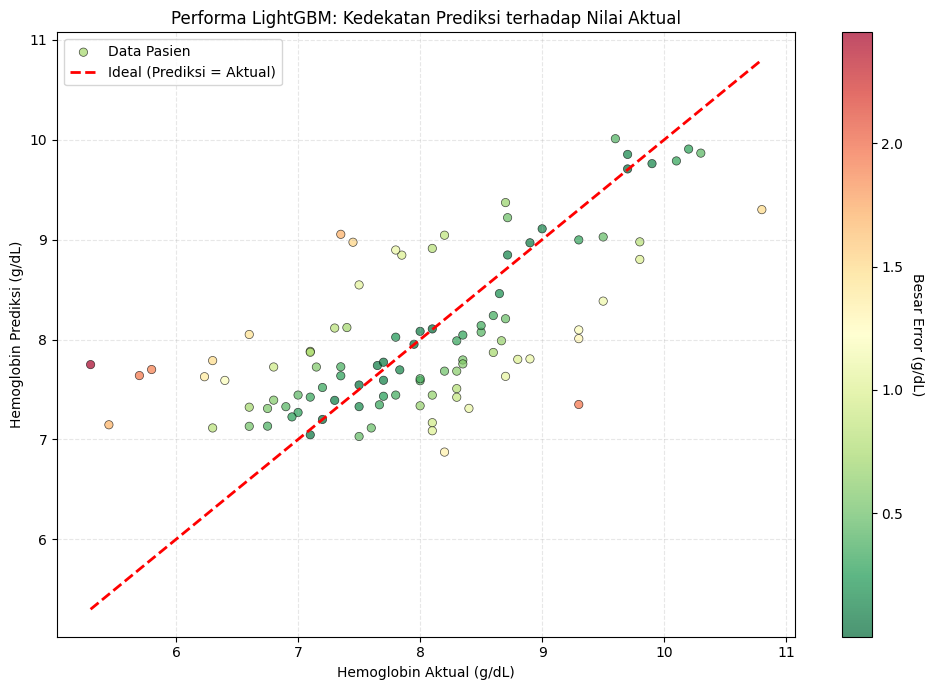

In [78]:
import numpy as np
import matplotlib.pyplot as plt

y_pred = models_final["LightGBM"].predict(X_test)
error_abs = np.abs(y_test - y_pred)

plt.figure(figsize=(10, 7))

# hijau untuk error kecil, merah untuk error besar)
scatter = plt.scatter(y_test, y_pred, 
                      c=error_abs, 
                      cmap='RdYlGn_r', 
                      alpha=0.7, 
                      edgecolors='k', 
                      linewidths=0.5,
                      label='Data Pasien')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Ideal (Prediksi = Aktual)')

cbar = plt.colorbar(scatter)
cbar.set_label('Besar Error (g/dL)', rotation=270, labelpad=15)

plt.xlabel("Hemoglobin Aktual (g/dL)")
plt.ylabel("Hemoglobin Prediksi (g/dL)")
plt.title("Performa LightGBM: Kedekatan Prediksi terhadap Nilai Aktual")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

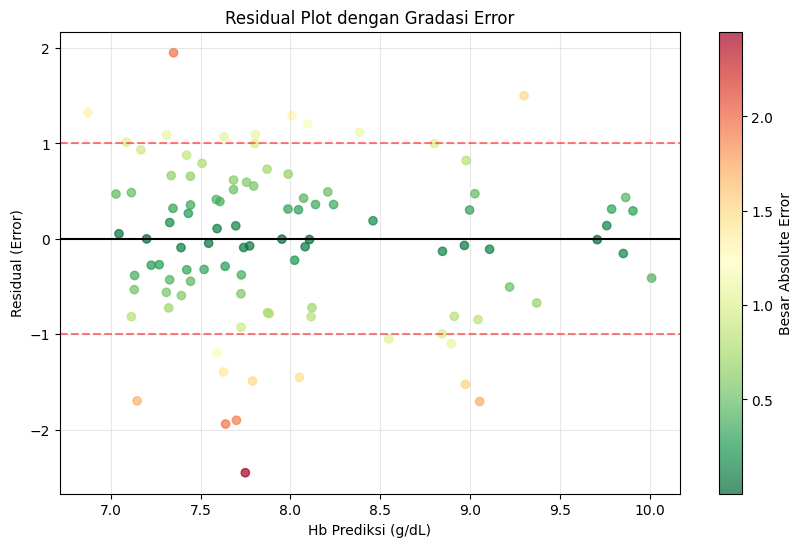

In [79]:
import numpy as np

# Hitung residual dan absolut error
residuals = y_test - y_pred
abs_error = np.abs(residuals)

plt.figure(figsize=(10, 6))

scatter = plt.scatter(y_pred, residuals, c=abs_error, cmap='RdYlGn_r', alpha=0.7)

plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5) # Garis pusat
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5)  # Batas error 1.0
plt.axhline(y=-1, color='red', linestyle='--', alpha=0.5) # Batas error -1.0

plt.colorbar(scatter, label='Besar Absolute Error')
plt.xlabel("Hb Prediksi (g/dL)")
plt.ylabel("Residual (Error)")
plt.title("Residual Plot dengan Gradasi Error")
plt.grid(True, alpha=0.3)
plt.show()

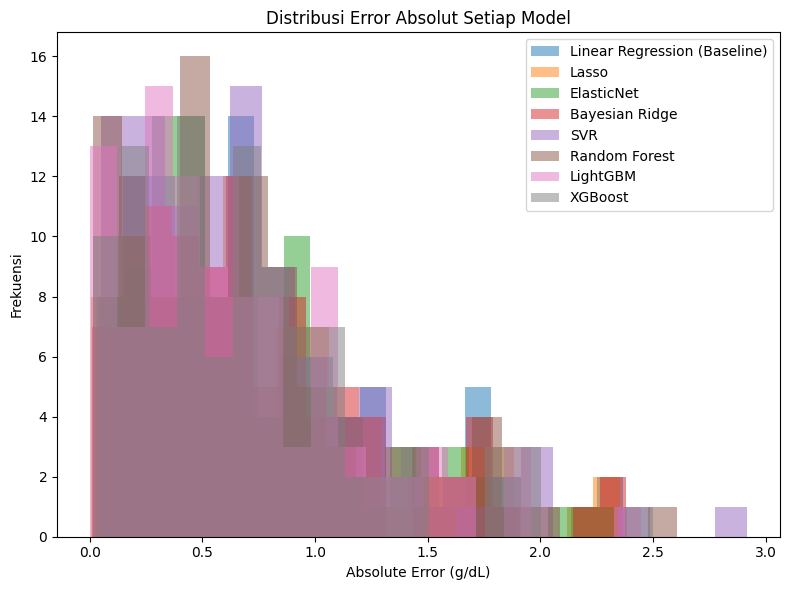

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models_final.items():
    y_pred = model.predict(X_test)
    abs_error = np.abs(y_test - y_pred)
    
    plt.hist(abs_error, bins=20, alpha=0.5, label=name)

plt.xlabel("Absolute Error (g/dL)")
plt.ylabel("Frekuensi")
plt.title("Distribusi Error Absolut Setiap Model")
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\Windows\AppData\Local\Temp\ipykernel_14576\3502629487.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(errors, labels=models_final.keys(), showfliers=False)


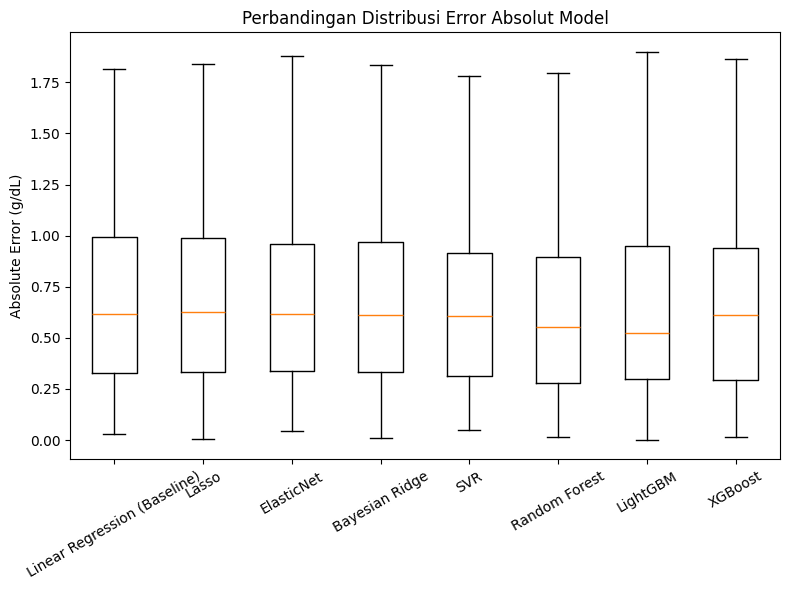

In [81]:
errors = []

for name, model in models_final.items():
    y_pred = model.predict(X_test)
    abs_error = np.abs(y_test - y_pred)
    errors.append(abs_error)

plt.figure(figsize=(8,6))
plt.boxplot(errors, labels=models_final.keys(), showfliers=False)
plt.ylabel("Absolute Error (g/dL)")
plt.title("Perbandingan Distribusi Error Absolut Model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
